<a href="https://colab.research.google.com/github/10dimensions/rl-notebooks/blob/main/sarsa_vs_qlearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy matplotlib gymnasium

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# ==========================================
# 1. Define the Slippery Cliff Environment
# ==========================================
class SlipperyCliff:
    def __init__(self, slip_prob=0.2):
        self.rows, self.cols = 4, 12
        self.n_states = self.rows * self.cols
        self.n_actions = 4  # 0:UP, 1:RIGHT, 2:DOWN, 3:LEFT
        self.slip_prob = slip_prob

        self.start_state = (3, 0)
        self.goal_state = (3, 11)
        self.cliff_states = [(3, c) for c in range(1, 11)]

        self.state = self.start_state

    def reset(self):
        self.state = self.start_state
        return self._state_to_int(self.state), {}

    def _state_to_int(self, s):
        return s[0] * self.cols + s[1]

    def _int_to_state(self, i):
        return (i // self.cols, i % self.cols)

    def step(self, action):
        # STOCHASTICITY: 20% chance to slip and take a random action
        if np.random.rand() < self.slip_prob:
            action = np.random.choice(self.n_actions)

        r, c = self.state
        # Apply action
        if action == 0: r = max(0, r - 1)      # UP
        elif action == 1: c = min(self.cols-1, c + 1) # RIGHT
        elif action == 2: r = min(self.rows-1, r + 1) # DOWN
        elif action == 3: c = max(0, c - 1)     # LEFT

        self.state = (r, c)
        reward = -1.0
        terminated = False

        # Check for Cliff
        if self.state in self.cliff_states:
            reward = -100.0
            terminated = True
            self.state = self.start_state # Reset to start on cliff fall
        # Check for Goal
        elif self.state == self.goal_state:
            terminated = True

        return self._state_to_int(self.state), reward, terminated, False, {}

In [4]:
# ==========================================
# 2. Training Functions (SARSA & Q-Learning)
# ==========================================
def get_epsilon_greedy_action(Q, state, epsilon, n_actions):
    if np.random.uniform() < epsilon:
        return np.random.choice(n_actions)
    else:
        return np.argmax(Q[state, :])

def train_agent(env, algorithm='qlearning', num_episodes=1000, alpha=0.5, gamma=0.99, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01):
    Q = np.zeros((env.n_states, env.n_actions))
    rewards_history = []

    for episode in range(num_episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False

        # SARSA requires knowing the next action BEFORE the update
        if algorithm == 'sarsa':
            action = get_epsilon_greedy_action(Q, state, epsilon, env.n_actions)

        while not done:
            if algorithm == 'qlearning':
                action = get_epsilon_greedy_action(Q, state, epsilon, env.n_actions)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            if algorithm == 'qlearning':
                # Off-policy: Bootstrap with max next Q-value
                if terminated:
                    td_target = reward
                else:
                    td_target = reward + gamma * np.max(Q[next_state, :])

            elif algorithm == 'sarsa':
                # On-policy: Bootstrap with the ACTUAL next action we will take
                next_action = get_epsilon_greedy_action(Q, next_state, epsilon, env.n_actions)
                if terminated:
                    td_target = reward
                else:
                    td_target = reward + gamma * Q[next_state, next_action]

            # Update Q-value
            Q[state, action] += alpha * (td_target - Q[state, action])

            state = next_state
            total_reward += reward

            if algorithm == 'sarsa':
                action = next_action # Crucial for SARSA: carry the action over to the next step

        rewards_history.append(total_reward)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, rewards_history

Training Q-Learning (Off-Policy)...
Training SARSA (On-Policy)...
Done!



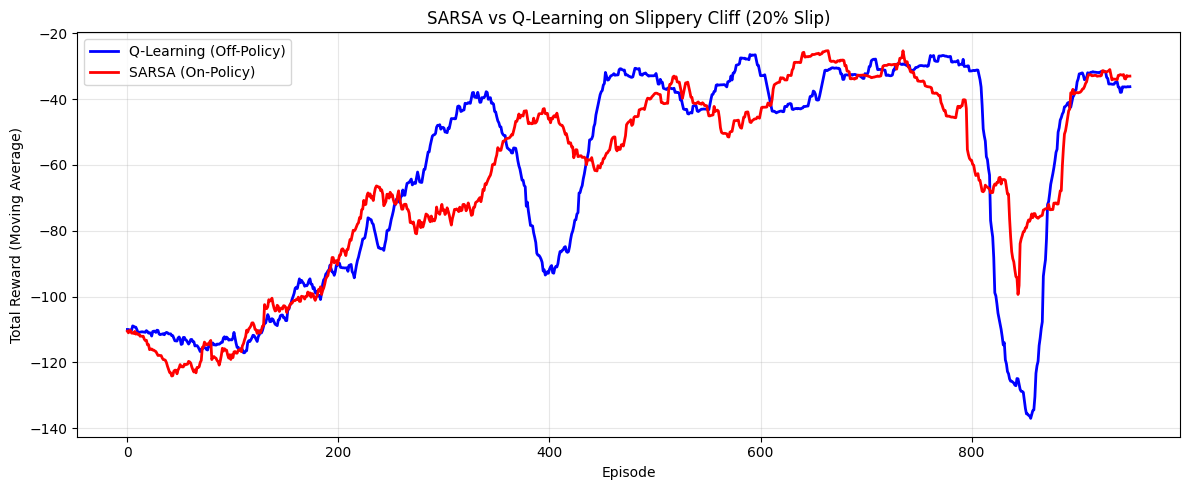

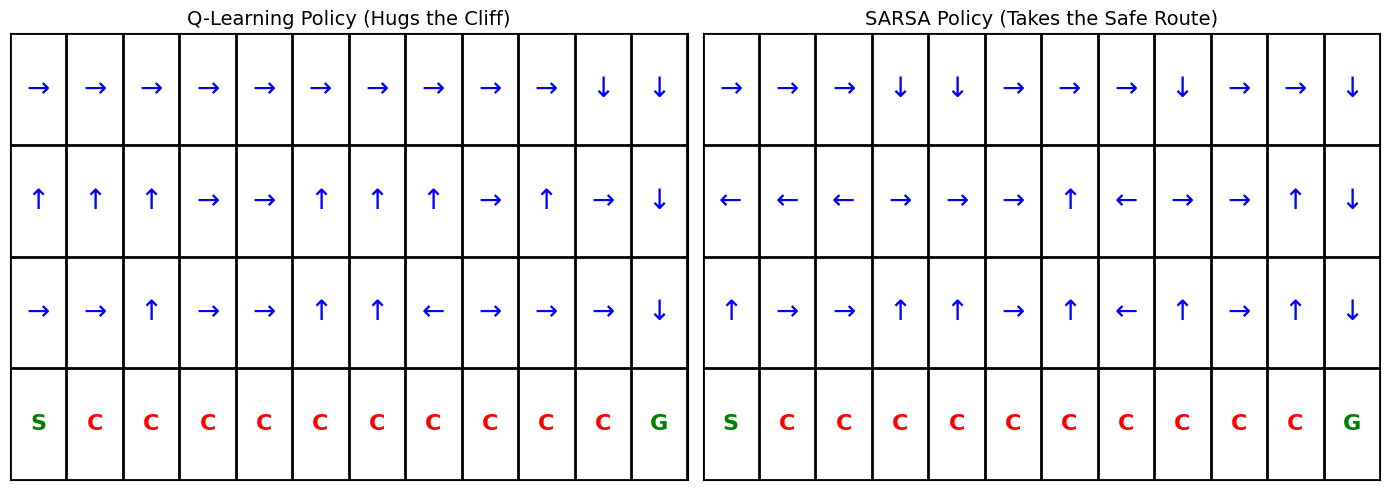

In [5]:

# ==========================================
# 3. Run and Compare
# ==========================================
if __name__ == "__main__":
    env = SlipperyCliff(slip_prob=0.2)

    print("Training Q-Learning (Off-Policy)...")
    Q_ql, rewards_ql = train_agent(env, algorithm='qlearning')

    print("Training SARSA (On-Policy)...")
    Q_sarsa, rewards_sarsa = train_agent(env, algorithm='sarsa')

    print("Done!\n")

    # ==========================================
    # 4. Plot Learning Curves
    # ==========================================
    plt.figure(figsize=(12, 5))

    # Smooth the curves
    window = 50
    smooth_ql = np.convolve(rewards_ql, np.ones(window)/window, mode='valid')
    smooth_sarsa = np.convolve(rewards_sarsa, np.ones(window)/window, mode='valid')

    plt.plot(smooth_ql, label='Q-Learning (Off-Policy)', color='blue', linewidth=2)
    plt.plot(smooth_sarsa, label='SARSA (On-Policy)', color='red', linewidth=2)

    plt.xlabel('Episode')
    plt.ylabel('Total Reward (Moving Average)')
    plt.title('SARSA vs Q-Learning on Slippery Cliff (20% Slip)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ==========================================
    # 5. Visualize Final Policies
    # ==========================================
    def plot_policy(Q, title, ax):
        arrows = {0: '↑', 1: '→', 2: '↓', 3: '←'}
        ax.set_title(title, fontsize=14)
        ax.set_xticks(np.arange(-.5, 12, 1), minor=True)
        ax.set_yticks(np.arange(-.5, 4, 1), minor=True)
        ax.grid(which="minor", color="black", linestyle='-', linewidth=2)
        ax.tick_params(which="minor", bottom=False, left=False)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.invert_yaxis()

        for r in range(4):
            for c in range(12):
                state = r * 12 + c
                if r == 3 and c == 0:
                    ax.text(c, r, 'S', ha='center', va='center', fontsize=16, color='green', fontweight='bold')
                elif r == 3 and c == 11:
                    ax.text(c, r, 'G', ha='center', va='center', fontsize=16, color='green', fontweight='bold')
                elif r == 3 and 0 < c < 11:
                    ax.text(c, r, 'C', ha='center', va='center', fontsize=16, color='red', fontweight='bold')
                else:
                    best_action = np.argmax(Q[state, :])
                    ax.text(c, r, arrows[best_action], ha='center', va='center', fontsize=20, color='blue')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    plot_policy(Q_ql, 'Q-Learning Policy (Hugs the Cliff)', ax1)
    plot_policy(Q_sarsa, 'SARSA Policy (Takes the Safe Route)', ax2)
    plt.tight_layout()
    plt.show()